In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('tokyo_weather.csv')

df.head(5)

,Date,Average Temperature (°C),Highest Temperature (°C),Highest Temperature (°C) Datetime,Lowest Temperature (°C),Lowest Temperature (°C) Datetime,Total Precipitation (mm),Sunshine Duration (hours),Maximum Snow Depth (cm),Maximum Snow Depth (cm) Datetime,...,Maximum Wind Speed (m/s) Datetime,Maximum Wind Speed (m/s) Direction,Maximum Gust Speed (m/s),Maximum Gust Speed (m/s) Datetime,Maximum Gust Speed (m/s) Direction,Most Frequent Wind Direction (16-point compass),Average Vapor Pressure (hPa),Average Humidity (%),Minimum Relative Humidity (%),Minimum Relative Humidity (%) Datetime
0,2018/6/26,25.7,30.1,2018/6/26 12:38,22.3,2018/6/26 5:37,0.0,9.2,0,NaN,...,2018/6/26 20:04,S,12.4,2018/6/26 21:03,SSW,SE,24.7,75,56,2018/6/26 12:29
1,2018/6/27,27.7,31.7,2018/6/27 12:55,24.9,2018/6/27 6:09,0.0,7.6,0,NaN,...,2018/6/27 14:10,SSW,20.0,2018/6/27 15:56,SW,SSW,26.1,71,57,2018/6/27 13:00
2,2018/6/28,27.4,31.9,2018/6/28 14:24,25.2,2018/6/28 7:53,0.0,4.8,0,NaN,...,2018/6/28 20:58,S,16.1,2018/6/28 23:59,SSW,SSW,27.9,77,60,2018/6/28 14:44
3,2018/6/29,28.2,32.9,2018/6/29 12:30,25.4,2018/6/29 4:43,0.0,12.8,0,NaN,...,2018/6/29 14:21,S,16.9,2018/6/29 8:31,SSW,S,27.7,73,55,2018/6/29 12:32
4,2018/6/30,28.6,32.7,2018/6/30 12:09,25.2,2018/6/30 4:34,0.0,13.1,0,NaN,...,2018/6/30 15:42,S,15.5,2018/6/30 15:24,SSE,S,28.5,74,57,2018/6/30 13:47


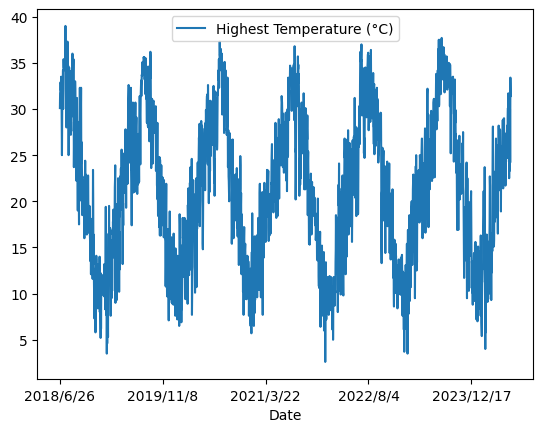

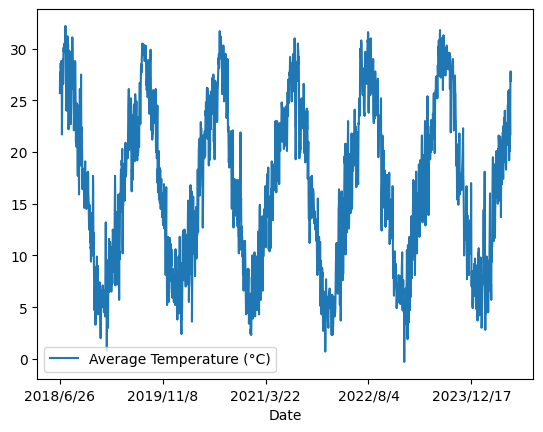

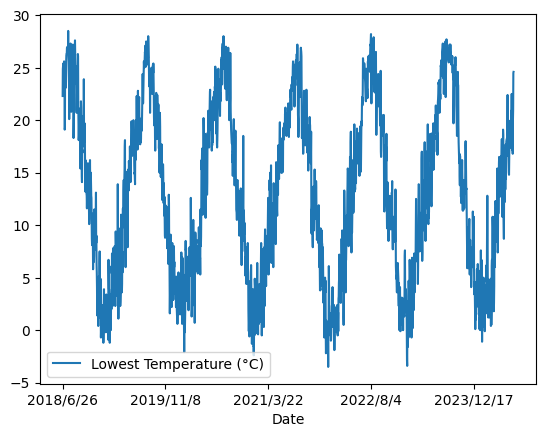

In [ ]:
import matplotlib.pyplot as plt
df.plot(x = 'Date' , y = 'Highest Temperature (°C)', kind="line")
plt.show()

df.plot(x = 'Date' , y = 'Average Temperature (°C)', kind="line")
plt.show()

df.plot(x = 'Date' , y = 'Lowest Temperature (°C)', kind="line")
plt.show()





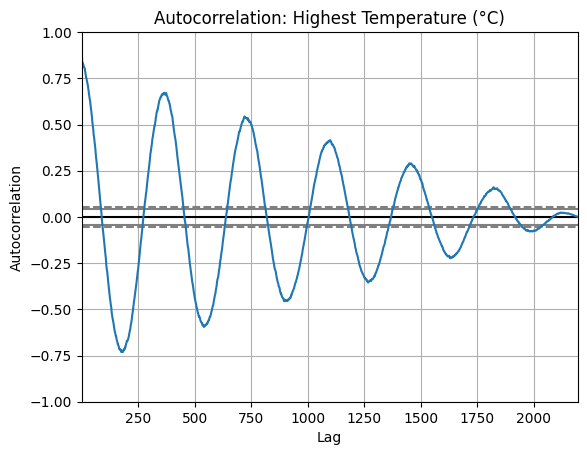

                                  SARIMAX Results                                   
Dep. Variable:     Highest Temperature (°C)   No. Observations:                 2193
Model:                       ARIMA(5, 1, 1)   Log Likelihood               -5561.004
Date:                      Mon, 27 Apr 2026   AIC                          11136.008
Time:                              22:03:13   BIC                          11175.856
Sample:                                   0   HQIC                         11150.572
                                     - 2193                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3438      0.040      8.579      0.000       0.265       0.422
ar.L2         -0.0119      0.026     -0.448      0.654      -0.064       0.040
ar.L

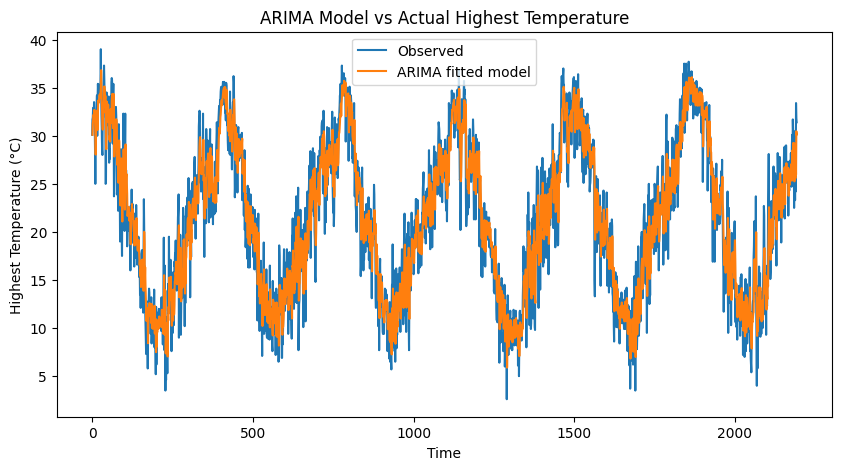

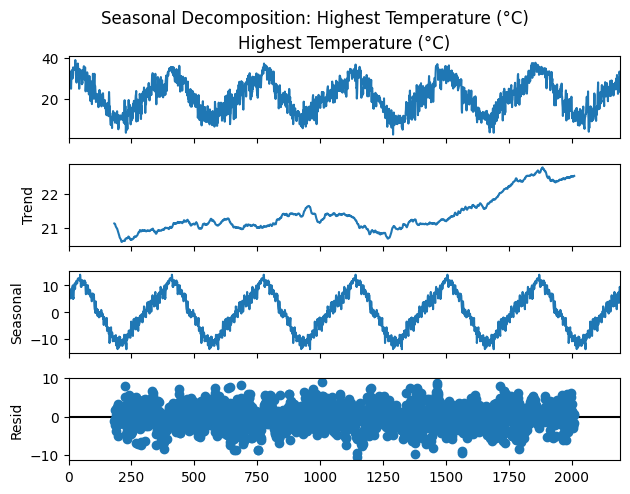

In [28]:

import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose


# Use the temperature column
x = df["Highest Temperature (°C)"]

# Autocorrelation plot
autocorrelation_plot(x)
plt.title("Autocorrelation: Highest Temperature (°C)")
plt.show()


# Build ARIMA
y = df["Highest Temperature (°C)"].dropna().reset_index(drop=True)

model = ARIMA(y, order=(5, 1, 1))


fit = model.fit()

# Print results
print(fit.summary())

# Fitted model values over existing data
fitted = fit.fittedvalues

# Plot actual data, fitted model
plt.figure(figsize=(10, 5))

plt.plot(y, label="Observed")
plt.plot(fitted.iloc[1:], label="ARIMA fitted model")


plt.title("ARIMA Model vs Actual Highest Temperature")
plt.xlabel("Time")
plt.ylabel("Highest Temperature (°C)")
plt.legend()
plt.show()


decomp = seasonal_decompose(y, model="additive", period=365)

decomp.plot()
plt.suptitle("Seasonal Decomposition: Highest Temperature (°C)", y=1.02)
plt.show()



C:\Users\GGPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                  SARIMAX Results                                   
Dep. Variable:     Highest Temperature (°C)   No. Observations:                 2173
Model:                     SARIMAX(5, 1, 1)   Log Likelihood               -5423.991
Date:                      Mon, 27 Apr 2026   AIC                          10873.982
Time:                              22:37:03   BIC                          10947.837
Sample:                                   0   HQIC                         10900.990
                                     - 2173                                         
Covariance Type:                        opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
trend            -3.3422      2.387     -1.400      0.161      -8.020       1.336
trend_squared     4.4009      2.189      2.010      0.044       0.110     

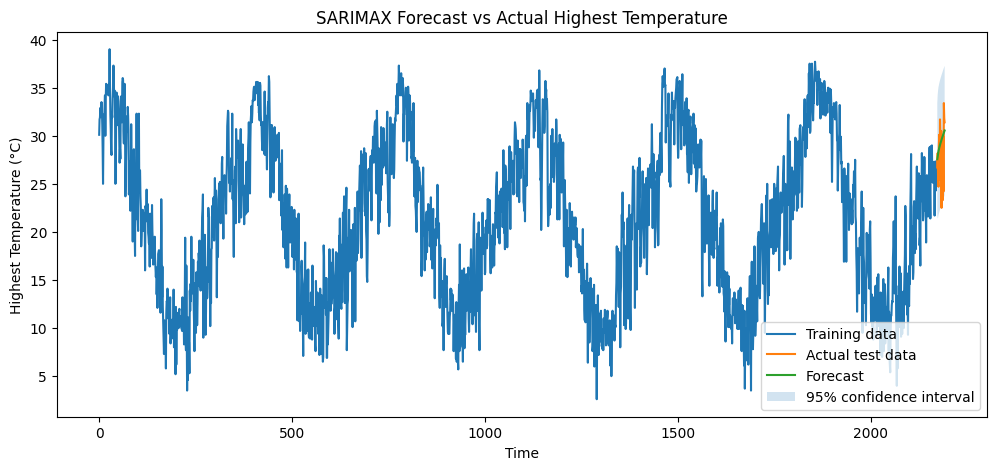

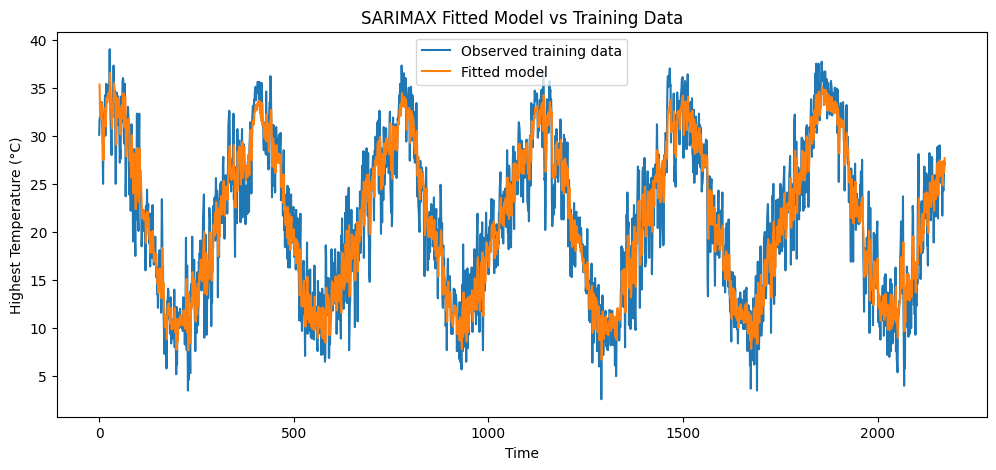

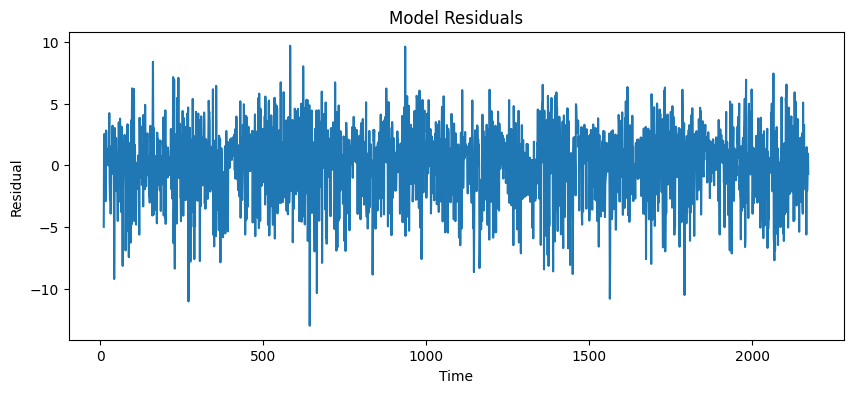

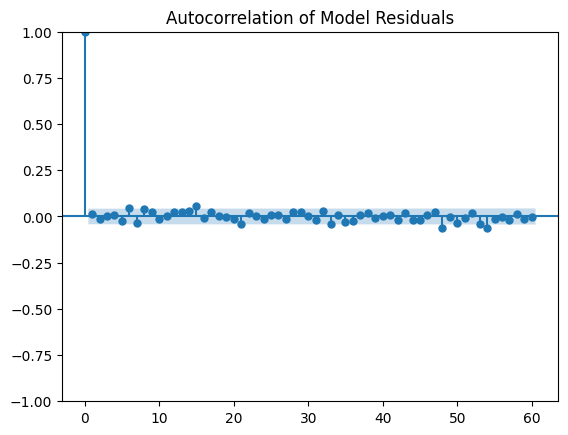

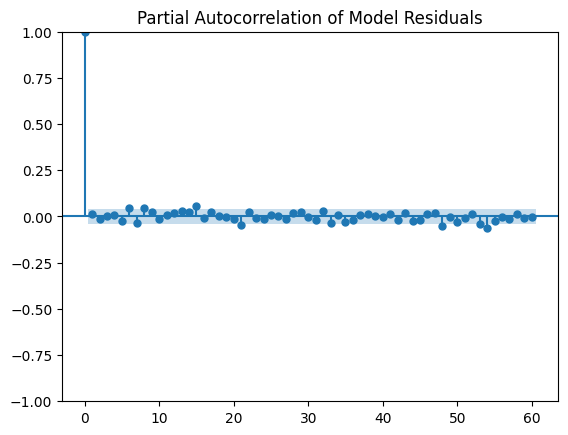

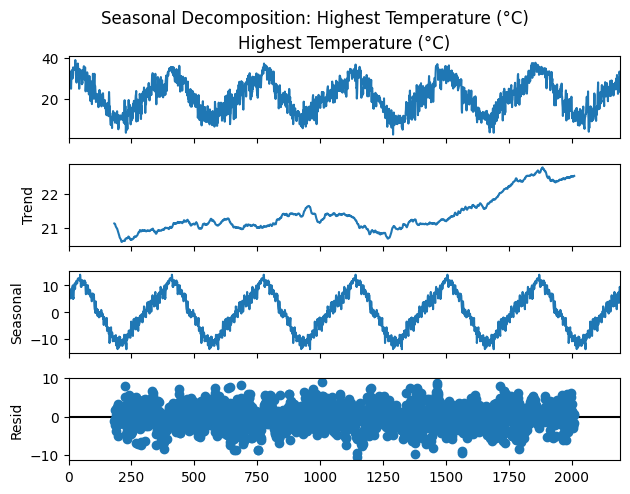

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# -------------------------------------------------
# Data
# -------------------------------------------------

y = df["Highest Temperature (°C)"].dropna().reset_index(drop=True)

# Make sure there is enough data
test_size = 20

if len(y) <= test_size:
    raise ValueError("Not enough data. Need more rows than test_size.")

# Time index
t = np.arange(len(y))

# Scale time for trend terms
t_scaled = t / len(y)

# Explanatory variables: trend + seasonal terms
X = pd.DataFrame({
    "trend": t_scaled,
    "trend_squared": t_scaled ** 2,

    "sin1": np.sin(2 * np.pi * t / 365),
    "cos1": np.cos(2 * np.pi * t / 365),

    "sin2": np.sin(4 * np.pi * t / 365),
    "cos2": np.cos(4 * np.pi * t / 365)
})

# -------------------------------------------------
# Train/test split
# -------------------------------------------------

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]

# -------------------------------------------------
# Fit SARIMAX model
# -------------------------------------------------

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(5, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=True)

print(fit.summary())

# -------------------------------------------------
# Forecast with confidence intervals
# -------------------------------------------------

pred = fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)

forecast = pred.predicted_mean
conf_int = pred.conf_int(alpha=0.05)   # 95% interval

# Match indexes
forecast.index = y_test.index
conf_int.index = y_test.index

conf_int.columns = ["lower_95", "upper_95"]

# -------------------------------------------------
# Print actual values, predictions, intervals, errors
# -------------------------------------------------

results = pd.DataFrame({
    "observed": y_test,
    "predicted": forecast,
    "lower_95": conf_int["lower_95"],
    "upper_95": conf_int["upper_95"]
})

results["error"] = results["observed"] - results["predicted"]
results["abs_error"] = results["error"].abs()

results["inside_95_interval"] = (
    (results["observed"] >= results["lower_95"]) &
    (results["observed"] <= results["upper_95"])
)

print("\nPrediction Results:")
print(results.round(2).to_string())

# -------------------------------------------------
# Accuracy measures
# -------------------------------------------------

mae = np.mean(results["abs_error"])
rmse = np.sqrt(np.mean(results["error"] ** 2))
mape = np.mean(np.abs(results["error"] / results["observed"])) * 100

print("\nModel Accuracy:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

# -------------------------------------------------
# Plot forecast vs actual
# -------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(y_train.index, y_train, label="Training data")
plt.plot(y_test.index, y_test, label="Actual test data")
plt.plot(y_test.index, forecast, label="Forecast")

plt.fill_between(
    y_test.index,
    conf_int["lower_95"],
    conf_int["upper_95"],
    alpha=0.2,
    label="95% confidence interval"
)

plt.title("SARIMAX Forecast vs Actual Highest Temperature")
plt.xlabel("Time")
plt.ylabel("Highest Temperature (°C)")
plt.legend()
plt.show()

# -------------------------------------------------
# Fitted values over training data
# -------------------------------------------------

fitted = fit.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(y_train, label="Observed training data")
plt.plot(fitted.iloc[1:], label="Fitted model")
plt.title("SARIMAX Fitted Model vs Training Data")
plt.xlabel("Time")
plt.ylabel("Highest Temperature (°C)")
plt.legend()
plt.show()

# -------------------------------------------------
# Check autocorrelation after model
# -------------------------------------------------

residuals = fit.resid.dropna()

# Drop first few because differencing can make early residuals odd
residuals = residuals.iloc[10:]

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Model Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

# Safe lag number
max_lags = min(60, len(residuals) // 2 - 1)

if max_lags > 0:
    plot_acf(residuals, lags=max_lags)
    plt.title("Autocorrelation of Model Residuals")
    plt.show()

    plot_pacf(residuals, lags=max_lags)
    plt.title("Partial Autocorrelation of Model Residuals")
    plt.show()

    lb_lags = [lag for lag in [10, 20, 30] if lag < len(residuals)]

    if len(lb_lags) > 0:
        lb_test = acorr_ljungbox(residuals, lags=lb_lags, return_df=True)

        print("\nLjung-Box Test:")
        print(lb_test.to_string())
else:
    print("\nNot enough residuals for ACF/PACF plots.")

# -------------------------------------------------
# Seasonal decomposition
# -------------------------------------------------

# seasonal_decompose needs about 2 full seasonal cycles
if len(y) >= 730:
    decomp = seasonal_decompose(y, model="additive", period=365)

    decomp.plot()
    plt.suptitle("Seasonal Decomposition: Highest Temperature (°C)", y=1.02)
    plt.show()
else:
    print("\nNot enough data for seasonal_decompose with period=365.")
    print("Need at least about 730 observations.")
print(results.round(2).to_string())